In [17]:
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from dotenv import load_dotenv
load_dotenv()

True

In [25]:
# define the Task schema
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description="What to cover")

In [38]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [39]:
# define the graph state.

class State(TypedDict):
    topic: str
    plan: Plan
    # reducer: results from workers get concatenated automatically
    sections: Annotated[List[str], operator.add]
    final: str


In [40]:
llm = ChatOpenAI(model="gpt-4.1-mini")

In [41]:
def orchestrator(state: State) -> dict:

    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=(
                    "Create a blog plan with 5-7 sections on the following topic."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    return {"plan": plan}

def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
            for task in state["plan"].tasks]

def worker(payload: dict) -> dict:

    # payload contains what we sent
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    section_md = llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}




from pathlib import Path

def reducer(state: State) -> dict:
    
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # ---- save to file ----
    filename = title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}


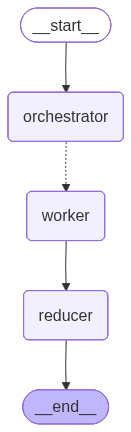

In [42]:


# define the stateGraph:

builder = StateGraph(State)
# add node.
builder.add_node('orchestrator', orchestrator)
builder.add_node('worker', worker)
builder.add_node('reducer', reducer)

# add edge.
builder.add_edge(START, "orchestrator")
builder.add_conditional_edges("orchestrator", fanout, ["worker"])
builder.add_edge("worker", "reducer")
builder.add_edge("reducer", END)

graph = builder.compile()

graph

In [43]:
out = graph.invoke({"topic": "Write a blog on Self Attention", "sections": []})
out

{'topic': 'Write a blog on Self Attention',
 'plan': Plan(blog_title='Understanding Self-Attention: The Core of Modern Neural Networks', tasks=[Task(id=1, title='Introduction to Self-Attention', brief='Explain what self-attention is and why it is important in the field of neural networks and deep learning.'), Task(id=2, title='The Mechanics of Self-Attention', brief='Describe how self-attention works, including key concepts like queries, keys, and values, and how they interact mathematically.'), Task(id=3, title='Self-Attention vs Traditional Attention Mechanisms', brief='Compare self-attention with other attention mechanisms, highlighting differences and advantages.'), Task(id=4, title='Applications of Self-Attention', brief='Discuss the applications of self-attention in various domains such as natural language processing, computer vision, and more.'), Task(id=5, title='Transformers: Leveraging Self-Attention', brief='Explain how self-attention is used in transformer architectures and